In [1]:
# Import required libraries
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, InputLayer, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.experimental.list_physical_devices('GPU'))


TensorFlow version: 2.18.0
GPU Available: []


In [2]:
# Load ECG heartbeat dataset
print("Loading ECG dataset...")

# Load training and test data
mitbih_train = pd.read_csv("dataset/mitbih_train.csv", header=None)
mitbih_test = pd.read_csv("dataset/mitbih_test.csv", header=None)

print(f"Training data shape: {mitbih_train.shape}")
print(f"Test data shape: {mitbih_test.shape}")

# Check class distribution
print("\nClass distribution in training data:")
print(mitbih_train[187].value_counts().sort_index())


Loading ECG dataset...
Training data shape: (87554, 188)
Test data shape: (21892, 188)

Class distribution in training data:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64


In [3]:
# Balance the dataset by upsampling minority classes
print("Balancing dataset...")

# Separate classes
df_0 = mitbih_train[mitbih_train[187] == 0].sample(n=20000, random_state=123)
df_1 = mitbih_train[mitbih_train[187] == 1]
df_2 = mitbih_train[mitbih_train[187] == 2]
df_3 = mitbih_train[mitbih_train[187] == 3]
df_4 = mitbih_train[mitbih_train[187] == 4]

# Upsample minority classes
df_1_upsample = resample(df_1, n_samples=20000, replace=True, random_state=123)
df_2_upsample = resample(df_2, n_samples=20000, replace=True, random_state=123)
df_3_upsample = resample(df_3, n_samples=20000, replace=True, random_state=123)
df_4_upsample = resample(df_4, n_samples=20000, replace=True, random_state=123)

# Combine all classes
mitbih_train_balanced = pd.concat([df_0, df_1_upsample, df_2_upsample, df_3_upsample, df_4_upsample])
mitbih_train_balanced = mitbih_train_balanced.sample(frac=1, random_state=123).reset_index(drop=True)

print(f"Balanced training data shape: {mitbih_train_balanced.shape}")
print("\nBalanced class distribution:")
print(mitbih_train_balanced[187].value_counts().sort_index())


Balancing dataset...
Balanced training data shape: (100000, 188)

Balanced class distribution:
187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64


In [4]:
# Prepare features and labels
print("Preparing features and labels...")

# Split features and labels
X_train = mitbih_train_balanced.iloc[:, :-1].values
y_train = mitbih_train_balanced.iloc[:, -1].values
X_test = mitbih_test.iloc[:, :-1].values
y_test = mitbih_test.iloc[:, -1].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Normalize features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for RNN input (samples, timesteps, features)
# For RNN: each ECG reading has 187 timesteps with 1 feature per timestep
X_train_rnn = X_train_scaled.reshape(-1, 187, 1)
X_test_rnn = X_test_scaled.reshape(-1, 187, 1)

print(f"RNN input shape - X_train: {X_train_rnn.shape}")
print(f"RNN input shape - X_test: {X_test_rnn.shape}")

# Compute class weights for handling any remaining imbalance
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")


Preparing features and labels...
X_train shape: (100000, 187)
y_train shape: (100000,)
X_test shape: (21892, 187)
y_test shape: (21892,)
RNN input shape - X_train: (100000, 187, 1)
RNN input shape - X_test: (21892, 187, 1)
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [5]:
# Build RNN Model with LSTM layers
def create_rnn_model(input_shape=(187, 1)):
    """
    Creates an RNN model using LSTM and GRU layers for ECG classification
    """
    model = Sequential([
        InputLayer(shape=input_shape),
        
        # First LSTM layer with return_sequences=True to stack layers
        LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Second LSTM layer
        LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Bidirectional LSTM for capturing patterns in both directions
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
        BatchNormalization(),
        
        # Dense layers for classification
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(5, activation='softmax')  # 5 classes for ECG types
    ])
    
    return model

# Create the model
print("Creating RNN model...")
rnn_model = create_rnn_model()

# Compile the model
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("\nModel Summary:")
rnn_model.summary()


Creating RNN model...

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 187, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 187, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,901 (941.02 KB)

 Trainable params: 240,261 (938.52 KB)

 Non-trainable params: 640 (2.50 KB)

In [6]:
# Alternative: Create GRU-based model (more efficient than LSTM)
def create_gru_model(input_shape=(187, 1)):
    """
    Creates an RNN model using GRU layers for faster training
    """
    model = Sequential([
        InputLayer(shape=input_shape),
        
        # GRU layers (faster than LSTM)
        GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Bidirectional GRU
        Bidirectional(GRU(64, dropout=0.2, recurrent_dropout=0.2)),
        BatchNormalization(),
        
        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(5, activation='softmax')
    ])
    
    return model

# Create GRU model
print("Creating GRU model...")
gru_model = create_gru_model()
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nGRU Model Summary:")
gru_model.summary()

# Choose which model to train (LSTM by default)
model_to_train = rnn_model  # Change to gru_model if you want to train GRU
model_name = "LSTM"  # Change to "GRU" accordingly


Creating GRU model...

GRU Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 187, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 187, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,229 (735.27 KB)

 Trainable params: 187,589 (732.77 KB)

 Non-trainable params: 640 (2.50 KB)

In [8]:
# Setup training callbacks
print("Setting up training callbacks...")

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

print("Callbacks configured successfully.")


Setting up training callbacks...
Callbacks configured successfully.


In [10]:
# Train the RNN model
print(f"Starting training of {model_name} model...")
print(f"Training data shape: {X_train_rnn.shape}")
print(f"Training labels shape: {y_train.shape}")

# Train the model
history = model_to_train.fit(
    X_train_rnn, y_train,
    validation_split=0.2,
    epochs=1,
    batch_size=64,  # Smaller batch size for RNN
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\n{model_name} model training completed!")


Starting training of LSTM model...
Training data shape: (100000, 187, 1)
Training labels shape: (100000,)
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 770s 616ms/step - accuracy: 0.6495 - loss: 0.8328 - val_accuracy: 0.8194 - val_loss: 0.4816 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

LSTM model training completed!


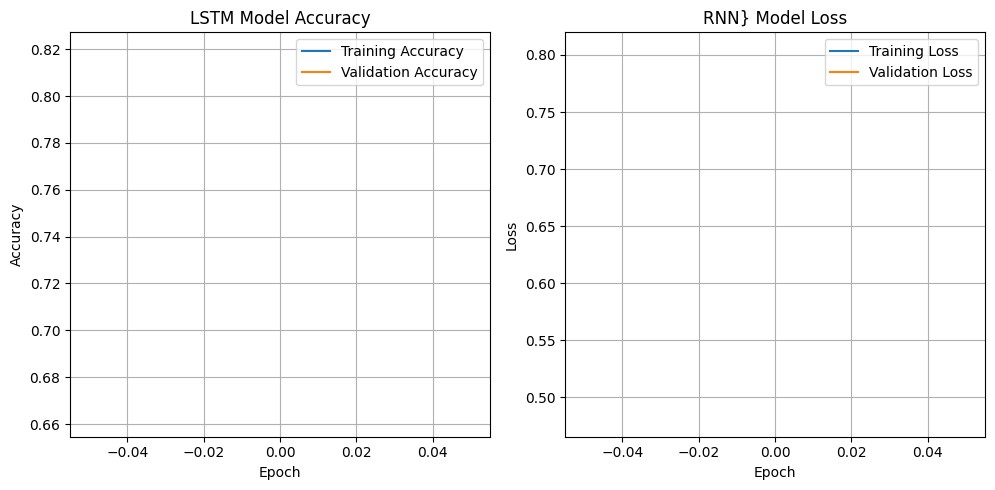


Final Training Accuracy: 0.6624
Final Validation Accuracy: 0.8194


In [11]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot training & validation accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'{model_name} Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN} Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot learning rate (if it was reduced)
if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'], label='Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Print final training metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [12]:
# Evaluate the model on test data
print("Evaluating model on test data...")

# Make predictions
y_pred_probs = model_to_train.predict(X_test_rnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate test accuracy
test_accuracy = model_to_train.evaluate(X_test_rnn, y_test, verbose=0)[1]
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Class names for better understanding
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print("\nClass Mapping:")
for i, name in enumerate(class_names):
    print(f"Class {i}: {name}")

# Display detailed results per class
print("\nDetailed Results:")
for i in range(5):
    class_mask = y_test == i
    if np.sum(class_mask) > 0:
        class_acc = np.sum(y_pred[class_mask] == i) / np.sum(class_mask)
        print(f"{class_names[i]} (Class {i}): {class_acc:.4f} accuracy, {np.sum(class_mask)} samples")


Evaluating model on test data...
685/685 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step

Test Accuracy: 0.7357

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.71      0.82     18118
         1.0       0.14      0.74      0.23       556
         2.0       0.51      0.83      0.63      1448
         3.0       0.09      0.85      0.16       162
         4.0       0.80      0.94      0.86      1608

    accuracy                           0.74     21892
   macro avg       0.50      0.81      0.54     21892
weighted avg       0.91      0.74      0.79     21892


Class Mapping:
Class 0: Normal
Class 1: Supraventricular
Class 2: Ventricular
Class 3: Fusion
Class 4: Unknown

Detailed Results:
Normal (Class 0): 0.7093 accuracy, 18118 samples
Supraventricular (Class 1): 0.7356 accuracy, 556 samples
Ventricular (Class 2): 0.8260 accuracy, 1448 samples
Fusion (Class 3): 0.8519 accuracy, 162 samples
Unknown (Class 4): 0.9397 accuracy, 1608 samples


<Figure size 1000x800 with 0 Axes>

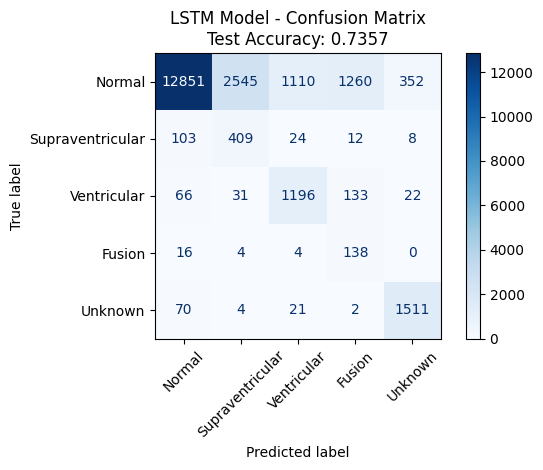


Confusion Matrix:
Predicted ->
Actual   |
[[12851  2545  1110  1260   352]
 [  103   409    24    12     8]
 [   66    31  1196   133    22]
 [   16     4     4   138     0]
 [   70     4    21     2  1511]]


In [13]:
# Create and display confusion matrix
plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('RNN  Model - Confusion Matrix\nTest Accuracy: {test_accuracy:.4f}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print confusion matrix values
print("\nConfusion Matrix:")
print("Predicted ->")
print("Actual   |")
print(cm)


In [ ]:
# Save the trained model
print("Saving the trained model...")

# Save the full model
model_to_train.save(f'ecg_{model_name.lower()}_model.h5')
print(f"Full model saved as: ecg_{model_name.lower()}_model.h5")

# Convert to TensorFlow Lite for mobile deployment
print("Converting to TensorFlow Lite...")

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model_to_train)
    
    # Use default optimization for RNN models
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    # Convert the model
    tflite_model = converter.convert()
    
    # Save TFLite model
    with open(f'assets/models/ecg_{model_name.lower()}_model.tflite', 'wb') as f:
        f.write(tflite_model)
    
    print(f"TensorFlow Lite model saved as: assets/models/ecg_{model_name.lower()}_model.tflite")
    
except Exception as e:
    print(f"Error converting to TFLite: {e}")
    print("RNN models with LSTM/GRU layers may have limited TFLite support.")
    print("Consider using the original CNN model for mobile deployment.")
